# Full Working Code - Gradient Descent

**Below is a fully working end-to-end code that:**

- Generates data
- Runs Batch GD, SGD, Mini-batch GD
- Stores costs properly
- Plots the comparison

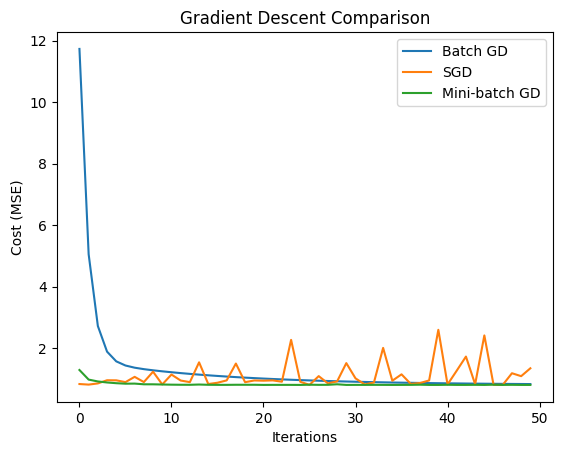

Batch GD Theta: [3.91125197 3.03839129]
SGD Theta: [4.00597696 2.27516959]
Mini-batch GD Theta: [4.21608467 2.77506002]


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1. Create Dataset
# ----------------------------
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Add bias term
X_b = np.c_[np.ones((100, 1)), X]

# ----------------------------
# 2. Common Settings
# ----------------------------
learning_rate = 0.1
n_iterations = 50
m = len(X_b)

# ----------------------------
# 3. Batch Gradient Descent
# ----------------------------
theta_batch = np.random.randn(2, 1)
batch_costs = []

for iteration in range(n_iterations):
    gradients = (2/m) * X_b.T @ (X_b @ theta_batch - y)
    theta_batch = theta_batch - learning_rate * gradients
    
    cost = np.mean((X_b @ theta_batch - y) ** 2)
    batch_costs.append(cost)

# ----------------------------
# 4. Stochastic Gradient Descent (SGD)
# ----------------------------
theta_sgd = np.random.randn(2, 1)
sgd_costs = []

for iteration in range(n_iterations):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        
        gradients = 2 * xi.T @ (xi @ theta_sgd - yi)
        theta_sgd = theta_sgd - learning_rate * gradients

    cost = np.mean((X_b @ theta_sgd - y) ** 2)
    sgd_costs.append(cost)

# ----------------------------
# 5. Mini-Batch Gradient Descent
# ----------------------------
theta_mini = np.random.randn(2, 1)
mini_costs = []

batch_size = 20

for iteration in range(n_iterations):
    indices = np.random.permutation(m)
    X_shuffled = X_b[indices]
    y_shuffled = y[indices]
    
    for i in range(0, m, batch_size):
        xi = X_shuffled[i:i+batch_size]
        yi = y_shuffled[i:i+batch_size]
        
        gradients = (2/len(xi)) * xi.T @ (xi @ theta_mini - yi)
        theta_mini = theta_mini - learning_rate * gradients

    cost = np.mean((X_b @ theta_mini - y) ** 2)
    mini_costs.append(cost)

# ----------------------------
# 6. Plot Comparison
# ----------------------------
plt.plot(batch_costs, label="Batch GD")
plt.plot(sgd_costs, label="SGD")
plt.plot(mini_costs, label="Mini-batch GD")

plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Comparison")
plt.legend()
plt.show()

# ----------------------------
# 7. Final Parameters
# ----------------------------
print("Batch GD Theta:", theta_batch.ravel())
print("SGD Theta:", theta_sgd.ravel())
print("Mini-batch GD Theta:", theta_mini.ravel())

**🧠 What you should observe**

- Batch GD → smooth curve
- SGD → noisy zig-zag
- Mini-batch → balanced

## Output Interpretation

```bash
Batch GD Theta:        [3.91, 3.03]
SGD Theta:             [4.00, 2.27]
Mini-batch GD Theta:   [4.21, 2.77]
```

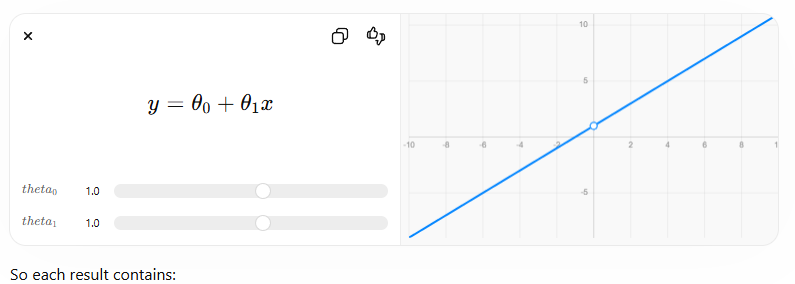

| Parameter | Meaning                |
| --------- | ---------------------- |
| θ₀        | intercept (base value) |
| θ₁        | slope (effect of X)    |


## 🎯 2. True Data Pattern (Ground Truth)

Remember your dataset:
```bash
y = 4 + 3x + noise

👉 True values:

Intercept ≈ 4
Slope ≈ 3
-----
Where:

4 = true intercept    (lets say its base line sales 4 unit (without any marketing cost))
3 = true slope
ε (noise) = randomness
```

### 🔍 3. Now compare each method

### 🔵 A. Batch Gradient Descent

```bash
Base:
[3.91, 3.03]
------------------------

Interpretation:
Intercept ≈ 3.91 (very close to 4)
Slope ≈ 3.03 (very close to 3)

🧠 Meaning:
✔ Most accurate
✔ Most stable
✔ Best convergence

👉 This is your benchmark solution
-----------------------------------------------------
🔴 B. Stochastic Gradient Descent (SGD)
Base : [3.91, 3.03]
SGD : [4.00, 2.27]

Interpretation:
Intercept = very close (good)
Slope = 2.27 (underestimated)
🧠 Meaning:
Learns fast but noisy
Didn’t fully converge
High variance in updates

👉 It “learns quickly but imperfectly”
-----------------------------------------------------
🟡 C. Mini-Batch Gradient Descent
Base        : [3.91, 3.03]
Mini-Batch  : [4.21, 2.77]

Interpretation:
Intercept slightly high
Slope slightly under true value
🧠 Meaning:
Balanced learning
Slight approximation error
Good generalization behavior

👉 This is real-world standard choice
===================================================

## 📊 4. Overall Comparison

| Method     | Accuracy | Stability | Speed         |
| ---------- | -------- | --------- | ------------- |
| Batch GD   | ⭐⭐⭐⭐⭐    | ⭐⭐⭐⭐⭐     | ❌ slow        |
| SGD        | ⭐⭐⭐      | ❌ noisy   | ⭐⭐⭐⭐⭐ fast    |
| Mini-batch | ⭐⭐⭐⭐     | ⭐⭐⭐⭐      | ⭐⭐⭐⭐ balanced |


## 🧠 5. Key Insight (Very Important)

All 3 methods are trying to find the same solution:

```bash

👉 y = 4 + 3x
---------------------
But differ in:
-> how they see data
-> how they update learning
-> how stable they are


### ⚡ 6. Why results are not identical?

```bash

Because of:

1. Random initialization
    starting θ is random
    
2. Noise in data
    you added np.random.randn

3. Update strategy difference
    batch = full knowledge
    SGD = single sample noise
    mini-batch = partial knowledge

## 🧠 7. Deep Intuition

```bash

Think of learning like this:
🔵 Batch GD:
    “I study everything before answering”

🔴 SGD:
    “I learn from each example instantly”

🟡 Mini-batch:
    “I learn from small groups of examples”

🏢 8. Business Interpretation

```bash
If this was your sales prediction model:

Batch GD:
    most reliable forecast
    slower decision-making
SGD:
    reacts quickly to market changes
    less stable predictions
Mini-batch:
    best balance for business forecasting systems

# Chapter 4

```bash
y = 4 + 3x + noise 
Interpretation: Intercept ≈ 3.91 (very close to 4) 
Slope ≈ 3.03 (very close to 3) 

Q1. Why its comparing 4 & 3 ?

🧠 1. Why are we comparing to 4 and 3?

Because 4 and 3 are the TRUE underlying rule used to generate your data.

```bash
Where:

4 = true intercept
3 = true slope
ε (noise) = randomness

```bash

🎯 2. What does this mean?

You are doing a simulation experiment:

👉 Step 1: You secretly define the real world rule
👉 Step 2: You generate data from it
👉 Step 3: You train a model to rediscover it

So now you ask:

“Did my model learn the correct rule?”

That’s why we compare:

| True value | Learned value |
| ---------- | ------------- |
| 4          | 3.91          |
| 3          | 3.03          |


🧠 3. Think of it like this (Analogy)

```bash
🎯 Hidden rule:

A vending machine is programmed:

Base price = 4
Per item cost = 3

But you don’t know this.

You only see:

noisy transactions
slightly random prices

Now you build a model to guess the pricing rule.

```bash
🚀 Bottom line

We compare to 4 and 3 only because they are the hidden “true rules” used to generate the dataset, so we can measure how well the model learned.